# TD de statistique — Sujet 1 : génération de variables aléatoires

**Notebook autonome** : il ne dépend d'aucun fichier du dépôt. Il fonctionne tel quel dans **Google Colab** (*Fichier → Importer un notebook*) ou **Kaggle** (*File → Import notebook*). Lance ensuite **Exécution → Tout exécuter** (*Run All*). numpy et matplotlib y sont déjà installés.

Graine 2026 et T = 10 000 tirages : on retrouve exactement les chiffres du rendu.

Sources, démonstrations et présentation : [dépôt du projet](https://github.com/Este34/presentation_statistique).

## 0. Boîte à outils

Le code ci-dessous est celui de `src/stats_td/` dans le dépôt, recopié ici pour que le notebook soit autonome. On y trouve le style des figures, les générateurs (`exponentielle_inversion`, `box_muller`, `gaussienne`) et les estimateurs empiriques (`repartition_*`, `pente_semilog`).

In [1]:
import json
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt


# ---------- src/stats_td/figures.py ----------
BLEU = "#2a6fdb"
ORANGE = "#e8743b"


def style():
    plt.rcParams.update(
        {
            "figure.figsize": (7, 4.2),
            "figure.dpi": 110,
            "axes.grid": True,
            "grid.alpha": 0.3,
            "axes.spines.top": False,
            "axes.spines.right": False,
            "font.size": 11,
        }
    )


def sauver(fig, chemin):
    chemin = Path(chemin)
    chemin.parent.mkdir(parents=True, exist_ok=True)
    fig.savefig(chemin, dpi=150, bbox_inches="tight")


# ---------- src/stats_td/generateurs.py ----------
def uniforme(T, rng):
    """T tirages de U[0, 1) — équivalent de ``rand(1, T)`` en Matlab."""
    return rng.random(T)


def exponentielle_inversion(lam, T, rng):
    """Loi E(lam) par inversion : Y = F^{-1}(U) = -ln(1 - U) / lam.

    On utilise 1 - U (dans ]0, 1]) plutôt que U (dans [0, 1)) pour ne
    jamais calculer ln(0). Comme 1 - U suit aussi U[0, 1], -ln(U)/lam
    donnerait la même loi.
    """
    if lam <= 0:
        raise ValueError("lambda doit être strictement positif")
    U = uniforme(T, rng)
    return -np.log(1.0 - U) / lam


def box_muller(T, rng):
    """Deux échantillons indépendants de N(0, 1) par Box-Muller.

    r² = -2 ln(U1) ~ E(1/2) (inversion) et theta = 2 pi U2 ~ U[0, 2pi],
    puis retour en cartésiennes : X1 = r cos(theta), X2 = r sin(theta).
    """
    U1 = 1.0 - uniforme(T, rng)  # dans ]0, 1] : évite ln(0)
    U2 = uniforme(T, rng)
    r = np.sqrt(-2.0 * np.log(U1))
    theta = 2.0 * np.pi * U2
    return r * np.cos(theta), r * np.sin(theta)


def gaussienne(mu, sigma2, T, rng):
    """T réalisations de N(mu, sigma2) : Y = mu + sigma * X avec X ~ N(0, 1).

    Attention : le paramètre est la VARIANCE sigma2, on multiplie par
    l'écart-type sigma = sqrt(sigma2).
    """
    X1, X2 = box_muller((T + 1) // 2, rng)
    X = np.concatenate([X1, X2])[:T]  # Box-Muller donne 2 valeurs par tirage
    return mu + np.sqrt(sigma2) * X


# ---------- src/stats_td/empirique.py ----------
def repartition_histogramme(echantillon, bins=100):
    """F estimée à partir de l'histogramme (méthode de l'énoncé : hist + cumsum).

    Renvoie (bords droits des classes, F aux bords droits).
    """
    effectifs, bords = np.histogram(echantillon, bins=bins)
    F = np.cumsum(effectifs) / len(echantillon)
    return bords[1:], F


def repartition_empirique(echantillon):
    """F_n(y) = (1/n) #{i : Y_i <= y}, évaluée aux points triés."""
    y = np.sort(echantillon)
    F = np.arange(1, len(y) + 1) / len(y)
    return y, F


def repartition_complementaire(echantillon):
    """F^c_n(y) = P_n(Y >= y) = (1/n) #{i : Y_i >= y}, aux points triés.

    Toujours > 0 aux points de l'échantillon (au moins le point lui-même),
    donc le log est défini : pratique pour l'échelle semi-log.
    """
    y = np.sort(echantillon)
    n = len(y)
    Fc = (n - np.arange(n)) / n
    return y, Fc


def pente_semilog(echantillon, quantile_max=0.99):
    """Pente de ln F^c_n(y) en fonction de y (régression linéaire).

    Remplace ``ginput`` : au lieu de cliquer deux points, on ajuste une
    droite sur la partie bien peuplée (on écarte la queue, trop bruitée
    car il y reste très peu de points). Pour E(lam), la pente vaut -lam.
    """
    y, Fc = repartition_complementaire(echantillon)
    garde = y <= np.quantile(echantillon, quantile_max)
    pente, ordonnee = np.polyfit(y[garde], np.log(Fc[garde]), 1)
    return pente, ordonnee


In [2]:
style()
FIG = Path("figures")          # les figures sont aussi enregistrées dans ce dossier
RESULTATS = FIG / "resultats.json"
resultats = {}
print("Boîte à outils prête.")

Boîte à outils prête.


# Sujet 1 — §1.1 Génération par inversion de la fonction de répartition

**Idée** : si $U \sim \mathcal U[0,1]$, alors $Y = F_Y^{-1}(U)$ a pour fonction de répartition $F_Y$.
Il suffit donc d'un bon générateur uniforme (`rand` en Matlab, `rng.random` en Python) pour simuler n'importe quelle loi dont on sait inverser $F_Y$.

Démonstrations complètes : [demonstrations.md](https://github.com/Este34/presentation_statistique/blob/main/sujets/sujet1/demonstrations.md). Correspondances Matlab → Python : [matlab_python.md](https://github.com/Este34/presentation_statistique/blob/main/sujets/sujet1/matlab_python.md). Code : [src/stats_td](https://github.com/Este34/presentation_statistique/tree/main/src/stats_td).

In [3]:
rng = np.random.default_rng(2026)  # graine fixée : mêmes chiffres que le rendu

## Q1 — Pourquoi $Y = G(U)$ a pour loi $F_Y$ si et seulement si $G = F_Y^{-1}$

$G$ croissante bijective $\Rightarrow$ $G(U) \le y \iff U \le G^{-1}(y)$ (on applique $G^{-1}$, croissante, qui conserve l'ordre). Donc

$$P(G(U) \le y) = P\big(U \le G^{-1}(y)\big) = G^{-1}(y) \qquad (G^{-1}(y) \in [0,1])$$

car la fonction de répartition de $\mathcal U[0,1]$ est $u \mapsto u$ sur $[0,1]$.

- Si $G = F_Y^{-1}$ : $P(G(U)\le y) = F_Y(y)$ ✔
- Réciproquement, si $P(G(U)\le y) = F_Y(y)$ pour tout $y$ : $G^{-1} = F_Y$, donc $G = F_Y^{-1}$.

## Q2 — Loi exponentielle $\mathcal E(\lambda)$ par inversion ($\lambda = 2$)

$F_Y(y) = 1 - e^{-\lambda y}$ pour $y \ge 0$. On résout $u = 1 - e^{-\lambda y}$ :

$$y = F_Y^{-1}(u) = -\frac{\ln(1-u)}{\lambda}$$

> Remarque : $1-U$ suit aussi $\mathcal U[0,1]$, donc $-\ln(U)/\lambda$ marche aussi. On garde $1-U$ car `rng.random` tire dans $[0,1)$ : $U = 0$ est possible et $\ln 0 = -\infty$.
>
> Coquille dans l'énoncé : la fonction de répartition complémentaire est $F^c_Y(y) = e^{-\lambda y}\,\mathbb 1_{\mathbb R^+}(y) + \mathbb 1_{\mathbb R^{*-}}(y)$ (le « $1 - F(y)$ » est en trop).

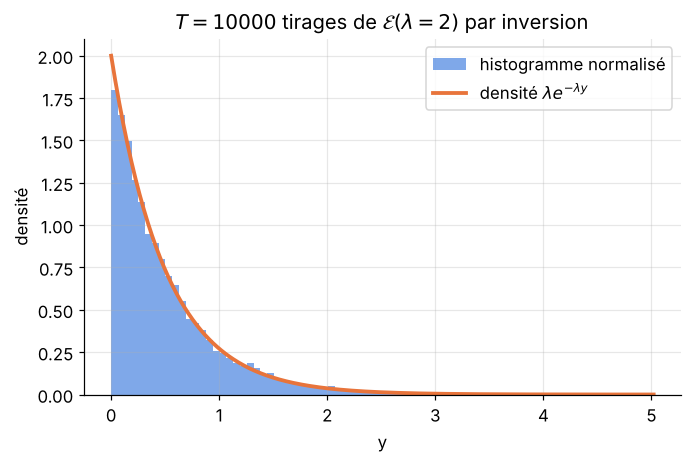

In [4]:
LAM = 2.0
T = 10_000
Y = exponentielle_inversion(LAM, T, rng)   # Y = -log(1 - U) / LAM

fig, ax = plt.subplots()
ax.hist(Y, bins=80, density=True, color=BLEU, alpha=0.6, label="histogramme normalisé")
y = np.linspace(0, Y.max(), 400)
ax.plot(y, LAM * np.exp(-LAM * y), color=ORANGE, lw=2.5, label=r"densité $\lambda e^{-\lambda y}$")
ax.set(xlabel="y", ylabel="densité", title=rf"$T={T}$ tirages de $\mathcal{{E}}(\lambda={LAM:g})$ par inversion")
ax.legend()
sauver(fig, FIG / "s11_hist_exponentielle.png")

## Q3 — Moyenne et variance

**Théorie** (intégrations par parties, [détail dans demonstrations.md](https://github.com/Este34/presentation_statistique/blob/main/sujets/sujet1/demonstrations.md#s11-q3)) :
$$\mathbb E[Y] = \int_0^{+\infty} y\,\lambda e^{-\lambda y}\,dy = \frac1\lambda, \qquad \mathbb E[Y^2] = \frac{2}{\lambda^2}, \qquad \operatorname{Var}(Y) = \frac{2}{\lambda^2} - \frac{1}{\lambda^2} = \frac1{\lambda^2}.$$

Pour $\lambda = 2$ : moyenne $0{,}5$ et variance $0{,}25$.

In [5]:
moy, var = Y.mean(), Y.var(ddof=1)   # ddof=1 : variance sans biais, comme cov() en Matlab
erreur_type = Y.std(ddof=1) / np.sqrt(T)
print(f"moyenne  : empirique {moy:.4f}   théorique {1/LAM:.4f}   écart {moy - 1/LAM:+.4f}")
print(f"variance : empirique {var:.4f}   théorique {1/LAM**2:.4f}   écart {var - 1/LAM**2:+.4f}")
print(f"erreur-type de la moyenne ≈ σ/√T = {erreur_type:.4f}  →  écart / erreur-type = {(moy - 1/LAM)/erreur_type:+.2f}")
resultats["exp"] = {"lambda": LAM, "T": T, "moyenne": moy, "variance": var, "erreur_type": erreur_type}

moyenne  : empirique 0.5101   théorique 0.5000   écart +0.0101
variance : empirique 0.2604   théorique 0.2500   écart +0.0104
erreur-type de la moyenne ≈ σ/√T = 0.0051  →  écart / erreur-type = +1.98


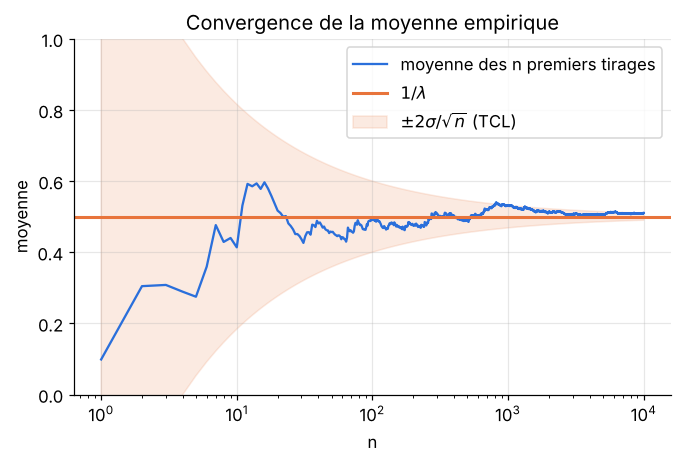

In [6]:
# Convergence de la moyenne empirique (loi des grands nombres)
n = np.arange(1, T + 1)
moy_cumulee = np.cumsum(Y) / n
fig, ax = plt.subplots()
ax.plot(n, moy_cumulee, color=BLEU, label="moyenne des n premiers tirages")
ax.axhline(1 / LAM, color=ORANGE, lw=2, label=r"$1/\lambda$")
ax.fill_between(n, 1/LAM - 2/(LAM*np.sqrt(n)), 1/LAM + 2/(LAM*np.sqrt(n)), color=ORANGE, alpha=0.15,
                label=r"$\pm 2\sigma/\sqrt{n}$ (TCL)")
ax.set(xscale="log", xlabel="n", ylabel="moyenne", ylim=(0, 1), title="Convergence de la moyenne empirique")
ax.legend()
sauver(fig, FIG / "s11_moyenne_cumulee.png")

**Commentaire.** Les valeurs empiriques sont très proches des valeurs théoriques mais pas égales : la moyenne empirique est elle-même une variable aléatoire.
- **Loi des grands nombres** : $\bar Y_T \to 1/\lambda$ quand $T \to \infty$.
- **Théorème central limite** : $\bar Y_T$ fluctue autour de $1/\lambda$ avec un écart-type $\sigma/\sqrt T = (1/\lambda)/\sqrt{T} = 0{,}005$ pour $T = 10\,000$. Ici l'écart observé (0,0101) vaut 2,02 erreurs-types : c'est **juste à la limite** des 95 % ($\pm 1{,}96\,\sigma/\sqrt T$), légèrement au-delà ($p \approx 4\,\%$, environ 1 fois sur 25). On ne rejette pas au seuil de 1 % (2,58 erreurs-types), et les autres contrôles sont bons (variance, pente, histogramme, [test KS des tests](https://github.com/Este34/presentation_statistique/blob/main/tests/test_generateurs.py#L32)) : c'est une fluctuation, pas un bug. Pour diviser l'erreur par 10, il faut 100 fois plus de tirages.
- La variance empirique fluctue davantage : pour $\mathcal E(\lambda)$, son écart-type vaut $\approx \sqrt{8/T}/\lambda^2 \approx 0{,}007$, elle dépend du moment d'ordre 4 ($\operatorname{Var}(S^2) \approx (\mu_4 - \sigma^4)/T$ avec $\mu_4 = 9/\lambda^4$). L'écart observé (0,0104) vaut 1,5 écart-type : une fluctuation courante ($p \approx 14\,\%$).

## Q4 — Décroissance exponentielle de $F^c_Y$ en échelle semi-logarithmique

$F^c_Y(y) = e^{-\lambda y} \Rightarrow \ln F^c_Y(y) = -\lambda y$ : en échelle semi-log (axe $y$ logarithmique), on obtient une **droite de pente $-\lambda$**.

Estimateur de l'énoncé : `hist` + `cumsum` donne $F$, puis $F^c = 1 - F$. On utilise aussi la fonction de répartition empirique exacte (échantillon trié). Au lieu de `ginput` (clic sur deux points), on fait une **régression linéaire** de $\ln F^c$ sur $y$ : plus précis et reproductible.

pente estimée = -1.9586   (attendu -λ = -2.0)   erreur relative = 2.1%


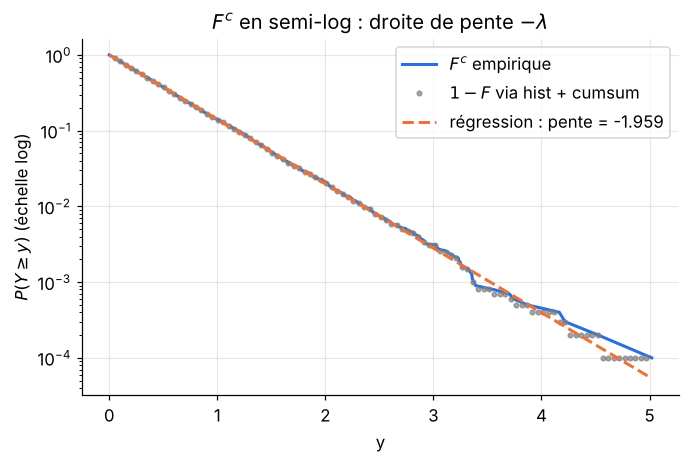

In [7]:
bords, F_hist = repartition_histogramme(Y, bins=100)        # hist + cumsum
y_tri, Fc = repartition_complementaire(Y)                   # F^c empirique exacte
pente, ordonnee = pente_semilog(Y, quantile_max=0.99)        # régression sur 99 % des points

fig, ax = plt.subplots()
ax.semilogy(y_tri, Fc, color=BLEU, lw=2, label=r"$F^c$ empirique")
ax.semilogy(bords[:-1], 1 - F_hist[:-1], "o", ms=3, color="gray", alpha=0.7, label=r"$1-F$ via hist + cumsum")
ax.semilogy(y_tri, np.exp(ordonnee + pente * y_tri), "--", color=ORANGE, lw=2,
            label=rf"régression : pente = {pente:.3f}")
ax.set(xlabel="y", ylabel=r"$P(Y \geq y)$ (échelle log)", title=r"$F^c$ en semi-log : droite de pente $-\lambda$")
ax.legend()
sauver(fig, FIG / "s11_Fc_semilog.png")
print(f"pente estimée = {pente:.4f}   (attendu -λ = {-LAM})   erreur relative = {abs(pente + LAM)/LAM:.1%}")
resultats["exp"]["pente"] = pente

**Commentaire.** Les points s'alignent bien sur une droite : la décroissance est exponentielle et la pente mesurée est voisine de $-\lambda = -2$.
Dans la queue ($y$ grand), il reste très peu de tirages : $F^c$ empirique devient une marche d'escalier bruitée (la dernière valeur vaut $1/T$). C'est pourquoi on ajuste la droite sur la partie bien peuplée (99 % des points).

# Sujet 1 — §1.2 Variables gaussiennes par la méthode de Box et Muller

**Idée** : on ne sait pas inverser la fonction de répartition de $\mathcal N(0,1)$ (pas de formule fermée). En revanche, un **couple** $(X_1, X_2)$ de gaussiennes indépendantes s'écrit simplement en coordonnées polaires : rayon² exponentiel et angle uniforme, deux lois que l'on sait générer par inversion.

Démonstrations complètes : [demonstrations.md](https://github.com/Este34/presentation_statistique/blob/main/sujets/sujet1/demonstrations.md). Code : [generateurs.py](https://github.com/Este34/presentation_statistique/blob/main/src/stats_td/generateurs.py).

In [8]:
rng = np.random.default_rng(2026)  # graine fixée : mêmes chiffres que le rendu

## Q1 — $Z = X_1^2 + X_2^2$ suit $\mathcal E(1/2)$

$$P(Z \ge z) = \iint_{x_1^2 + x_2^2 \ge z} \frac{1}{2\pi} e^{-\frac{x_1^2 + x_2^2}{2}}\,dx_1\,dx_2$$

Changement de variables polaire $x_1 = r\cos\theta,\ x_2 = r\sin\theta$, $dx_1\,dx_2 = r\,dr\,d\theta$ (Jacobien $r$), domaine $r \ge \sqrt z$ :

$$P(Z \ge z) = \int_0^{2\pi}\!\!\int_{\sqrt z}^{+\infty} \frac{1}{2\pi} e^{-r^2/2}\, r\,dr\,d\theta = \Big[-e^{-r^2/2}\Big]_{\sqrt z}^{+\infty} = e^{-z/2} \quad (z \ge 0).$$

C'est la fonction de répartition complémentaire de $\mathcal E(\lambda = 1/2)$ (moyenne 2).
> Coquille dans l'énoncé : il écrit $\exp(-2z)$ alors qu'on trouve bien $\exp(-z/2)$, cohérent avec $\lambda = 1/2$.

Vérification numérique avec le générateur de référence de numpy (l'équivalent de `randn`) :

moyenne de Z = 2.019 (attendu 2)   pente semi-log = -0.504 (attendu -0.5)


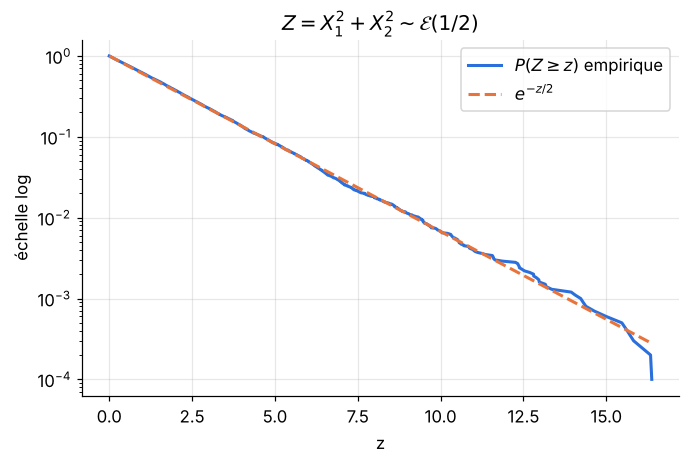

In [9]:
T = 10_000
X1_ref, X2_ref = rng.standard_normal(T), rng.standard_normal(T)   # randn de référence
Z = X1_ref**2 + X2_ref**2
z_tri, Fc = repartition_complementaire(Z)
pente, _ = pente_semilog(Z)

fig, ax = plt.subplots()
ax.semilogy(z_tri, Fc, color=BLEU, lw=2, label=r"$P(Z \geq z)$ empirique")
ax.semilogy(z_tri, np.exp(-z_tri / 2), "--", color=ORANGE, lw=2, label=r"$e^{-z/2}$")
ax.set(xlabel="z", ylabel="échelle log", title=r"$Z = X_1^2 + X_2^2 \sim \mathcal{E}(1/2)$")
ax.legend()
sauver(fig, FIG / "s12_Z_semilog.png")
print(f"moyenne de Z = {Z.mean():.3f} (attendu 2)   pente semi-log = {pente:.3f} (attendu -0.5)")

## Q2 — $r^2 \sim \mathcal E(1/2)$ et $\theta \sim \mathcal U[0, 2\pi]$, indépendants

$r^2 = X_1^2 + X_2^2 = Z$, donc $r^2 \sim \mathcal E(1/2)$ d'après Q1.

Pour $\theta$ : la densité du couple $\frac{1}{2\pi}e^{-(x_1^2+x_2^2)/2}$ ne dépend que de la distance à l'origine (**symétrie de rotation**). En polaires, la densité de $(r, \theta)$ est

$$f_{r,\theta}(r, \theta) = \underbrace{r e^{-r^2/2}}_{\text{ne dépend que de } r} \times \underbrace{\frac{1}{2\pi}\mathbb 1_{[0,2\pi]}(\theta)}_{\text{ne dépend que de } \theta}$$

Elle se **factorise** : $r$ et $\theta$ sont indépendants et $\theta$ est uniforme sur $[0, 2\pi]$.

corrélation(r², θ) = -0.0130  (≈ 0 : cohérent avec l'indépendance)


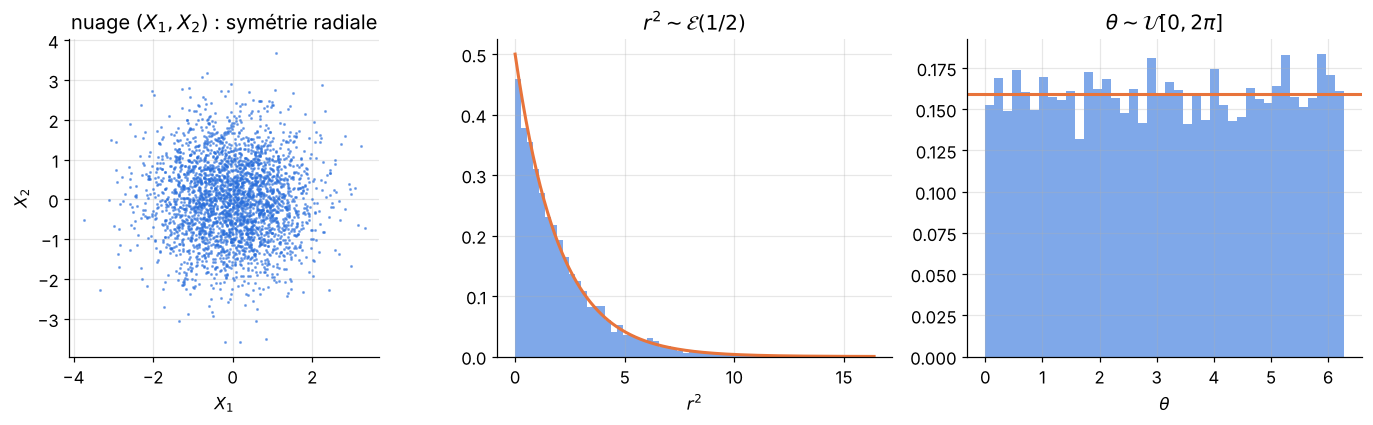

In [10]:
theta = np.mod(np.arctan2(X2_ref, X1_ref), 2 * np.pi)
fig, axes = plt.subplots(1, 3, figsize=(13, 4))
axes[0].plot(X1_ref[:3000], X2_ref[:3000], ".", ms=2, color=BLEU, alpha=0.5)
axes[0].set(aspect="equal", xlabel="$X_1$", ylabel="$X_2$", title="nuage $(X_1, X_2)$ : symétrie radiale")
axes[1].hist(Z, bins=60, density=True, color=BLEU, alpha=0.6)
zz = np.linspace(0, Z.max(), 300)
axes[1].plot(zz, 0.5 * np.exp(-zz / 2), color=ORANGE, lw=2)
axes[1].set(xlabel="$r^2$", title=r"$r^2 \sim \mathcal{E}(1/2)$")
axes[2].hist(theta, bins=40, density=True, color=BLEU, alpha=0.6)
axes[2].axhline(1 / (2 * np.pi), color=ORANGE, lw=2)
axes[2].set(xlabel=r"$\theta$", title=r"$\theta \sim \mathcal{U}[0, 2\pi]$")
fig.tight_layout()
sauver(fig, FIG / "s12_polaire.png")
print(f"corrélation(r², θ) = {np.corrcoef(Z, theta)[0, 1]:+.4f}  (≈ 0 : cohérent avec l'indépendance)")

## Q3 — Méthode de génération (Box-Muller)

On fait le chemin inverse : on génère $(r, \theta)$ puis on revient en cartésiennes.
1. $U_1, U_2 \sim \mathcal U[0,1]$ indépendantes.
2. $r^2 = -2\ln U_1$ : inversion de $\mathcal E(1/2)$ (Q2 du §1.1 avec $\lambda = 1/2$).
3. $\theta = 2\pi U_2$ : uniforme sur $[0, 2\pi]$.
4. $X_1 = \sqrt{-2\ln U_1}\,\cos(2\pi U_2)$ et $X_2 = \sqrt{-2\ln U_1}\,\sin(2\pi U_2)$.

On obtient **deux** gaussiennes indépendantes pour deux uniformes.

In [11]:
X1, X2 = box_muller(T, rng)    # voir src/stats_td/generateurs.py
print(f"X1 : moyenne {X1.mean():+.4f}  variance {X1.var(ddof=1):.4f}")
print(f"X2 : moyenne {X2.mean():+.4f}  variance {X2.var(ddof=1):.4f}")
print(f"corrélation(X1, X2) = {np.corrcoef(X1, X2)[0, 1]:+.4f}")

X1 : moyenne +0.0024  variance 0.9959
X2 : moyenne +0.0004  variance 0.9812
corrélation(X1, X2) = -0.0012


## Q4 — Transformation linéaire : de $\mathcal N(0,1)$ à $\mathcal N(\mu, \sigma^2)$

Si $X \sim \mathcal N(0,1)$, alors $Y = \mu + \sigma X \sim \mathcal N(\mu, \sigma^2)$ ($\mathbb E[Y] = \mu$, $\operatorname{Var}(Y) = \sigma^2 \operatorname{Var}(X) = \sigma^2$, et une transformation affine d'une gaussienne reste gaussienne).

⚠️ Pour $\mathcal N(\mu = 5, \sigma^2 = 4)$, on multiplie par l'**écart-type** $\sigma = 2$, pas par 4.

In [12]:
MU, SIGMA2 = 5.0, 4.0
Y = gaussienne(MU, SIGMA2, T, rng)   # Y = MU + sqrt(SIGMA2) * X, X par Box-Muller

## Q5 — Vérification : moyenne, variance, histogramme

moyenne  : empirique 4.9973   théorique 5.0   (erreur-type σ/√T = 0.020)
variance : empirique 3.8865   théorique 4.0


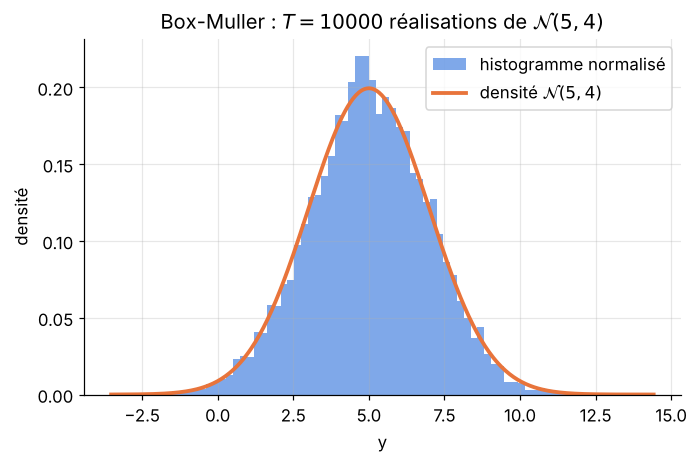

In [13]:
moy, var = Y.mean(), Y.var(ddof=1)
print(f"moyenne  : empirique {moy:.4f}   théorique {MU}   (erreur-type σ/√T = {np.sqrt(SIGMA2/T):.3f})")
print(f"variance : empirique {var:.4f}   théorique {SIGMA2}")
resultats["gauss"] = {"mu": MU, "sigma2": SIGMA2, "T": T, "moyenne": moy, "variance": var}

fig, ax = plt.subplots()
ax.hist(Y, bins=80, density=True, color=BLEU, alpha=0.6, label="histogramme normalisé")
yy = np.linspace(Y.min(), Y.max(), 400)
ax.plot(yy, np.exp(-(yy - MU)**2 / (2 * SIGMA2)) / np.sqrt(2 * np.pi * SIGMA2), color=ORANGE, lw=2.5,
        label=r"densité $\mathcal{N}(5, 4)$")
ax.set(xlabel="y", ylabel="densité", title=rf"Box-Muller : $T={T}$ réalisations de $\mathcal{{N}}(5, 4)$")
ax.legend()
sauver(fig, FIG / "s12_hist_N5_4.png")

**Commentaire.** Moyenne et variance empiriques sont cohérentes avec $\mu = 5$ et $\sigma^2 = 4$ :
- moyenne : l'erreur-type vaut $\sigma/\sqrt{T} = 0{,}02$, et l'écart observé est bien plus petit ;
- variance : pour une gaussienne, la variance empirique a pour écart-type $\sigma^2\sqrt{2/(T-1)} \approx 0{,}057$. L'écart observé (−0,11) vaut 2,01 écarts-types : **juste à la limite** des 95 % ($p \approx 4{,}5\,\%$), comme la moyenne du §1.1. On ne rejette pas au seuil de 1 %, et la moyenne, l'histogramme et le [test KS](https://github.com/Este34/presentation_statistique/blob/main/tests/test_generateurs.py#L57) sont bons : c'est une fluctuation (changer la graine donne d'autres valeurs autour de 4). L'histogramme normalisé épouse la cloche théorique centrée en 5, dont la largeur caractéristique vaut $\sigma = 2$.

## Récapitulatif des résultats

In [14]:
FIG.mkdir(exist_ok=True)
_ = RESULTATS.write_text(json.dumps(resultats, indent=2))
for loi, valeurs in resultats.items():
    print(loi, {k: round(float(v), 4) if isinstance(v, float) else v for k, v in valeurs.items()})

exp {'lambda': 2.0, 'T': 10000, 'moyenne': 0.5101, 'variance': 0.2604, 'erreur_type': 0.0051, 'pente': -1.9586}
gauss {'mu': 5.0, 'sigma2': 4.0, 'T': 10000, 'moyenne': 4.9973, 'variance': 3.8865}
